# 02 — Qualité des données & hallucinations

**Cadre :** avant tout modèle, auditer la fiabilité des sources cliniques hétérogènes (sujet CISIA).

Ce notebook documente **toutes** les anomalies injectées volontairement dans les données synthétiques :

| Catégorie | Définition | Où c'est détecté |
|-----------|------------|------------------|
| **Trous** | Valeurs manquantes / vides | `quality_report.py` |
| **Aberrantes** | Hors plage physiologique ou biologique | `vitals.py`, `quality.py` |
| **Mal notées** | Incohérences métier (« hallucinations ») | durée séjour, TAD≥TAS, actes hors séjour… |
| **Sensibilité IA** | Colonnes RGPD & usage modèle | `registre.py` |

Synthèse complète (nulls + dates + patho) : [05_analyse_donnees](05_analyse_donnees.ipynb)  
Rapport HTML : `data/curated/qualite/rapport_qualite.html`


In [7]:
import runpy
from pathlib import Path
_sp = next(a / "setup_path.py" for a in [Path.cwd(), *Path.cwd().parents] if (a / "setup_path.py").is_file())
runpy.run_path(str(_sp))

%matplotlib inline
from _utils.bootstrap import ROOT, paths, COLORS
from _utils.qualite_data import collecter_exemples_hallucinations
from _utils.qualite_plots import plot_dataset_qualite, plot_sensibilite_ia, plot_synthese_globale
from src.data.quality_report import export_quality_report, run_quality_report
from IPython.display import display, Markdown
import pandas as pd

report = run_quality_report(paths)
print(f"Fichiers analysés : {len(report['datasets'])}")


Fichiers analysés : 11


## Synthèse globale (tous fichiers)

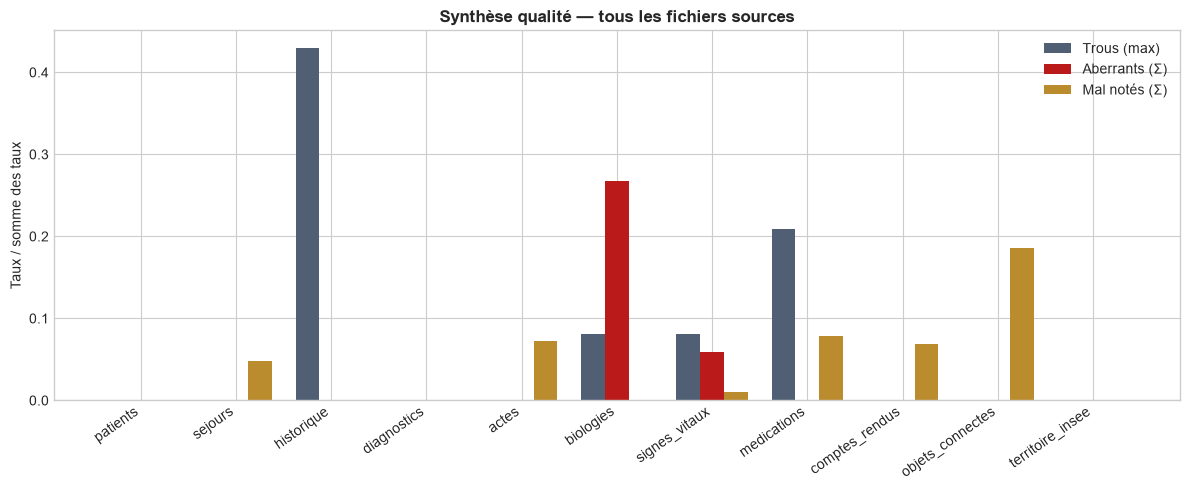

In [2]:
plot_synthese_globale(report)

## Détail par fichier CSV

Pour chaque source : 4 graphiques (trous, aberrants, mal notés, synthèse) + sensibilité IA si applicable.

### `patients.csv` — 620 lignes

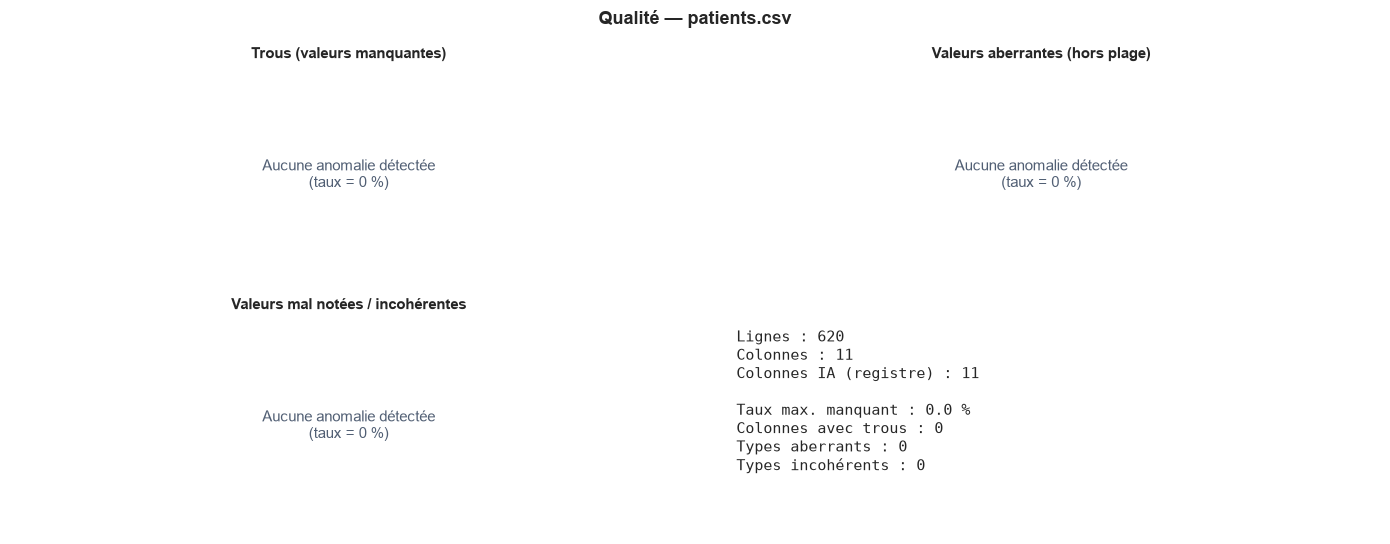

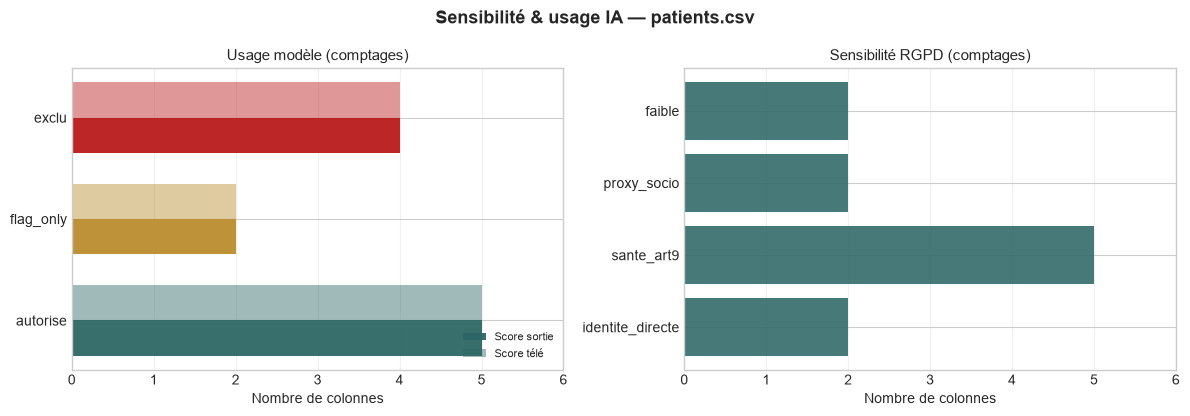

**Détail colonnes — `patients.csv`**

,colonne,sensibilite,usage_score_sortie,usage_score_tele,risque_principal
0,CodePostal,sante_art9,autorise,autorise,qualite
1,Commune,sante_art9,autorise,autorise,qualite
2,DateNaissance,sante_art9,autorise,autorise,qualite
3,PathologiesChroniques,sante_art9,autorise,autorise,qualite
4,Sexe,sante_art9,autorise,autorise,qualite
5,MedecinTraitant,faible,exclu,exclu,biais
6,PatientID,faible,exclu,exclu,none
7,NomPrenom,identite_directe,exclu,exclu,secret_medical
8,PersonneAPrevenir,identite_directe,exclu,exclu,secret_medical
9,RegimeAssurance,proxy_socio,flag_only,flag_only,biais


### `sejours.csv` — 878 lignes

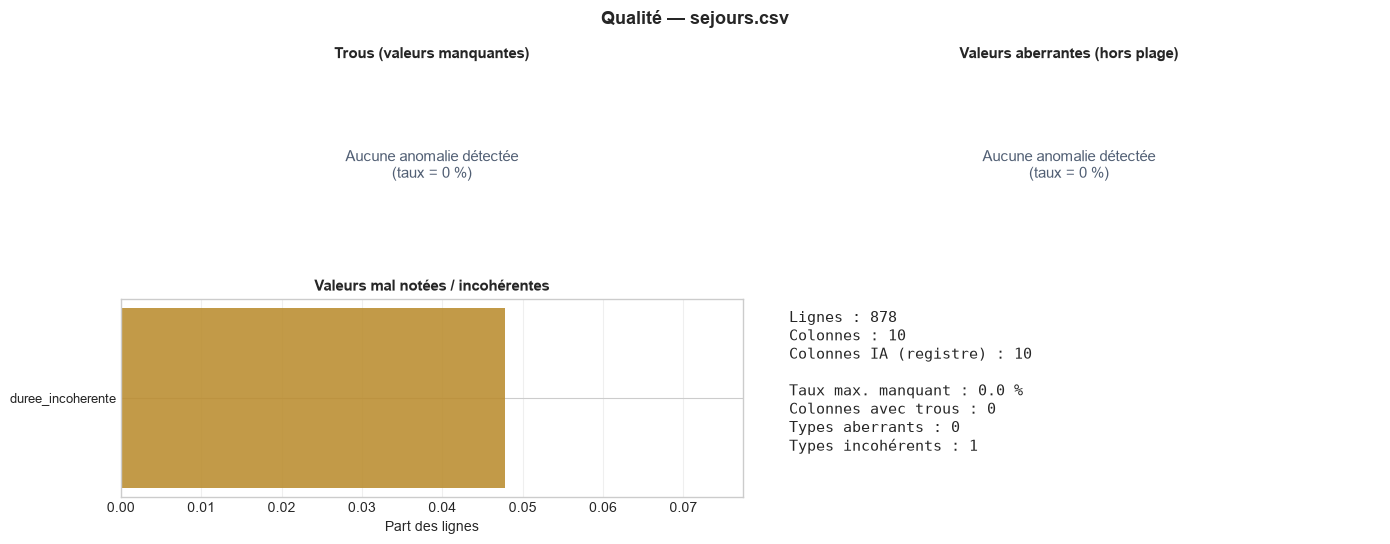

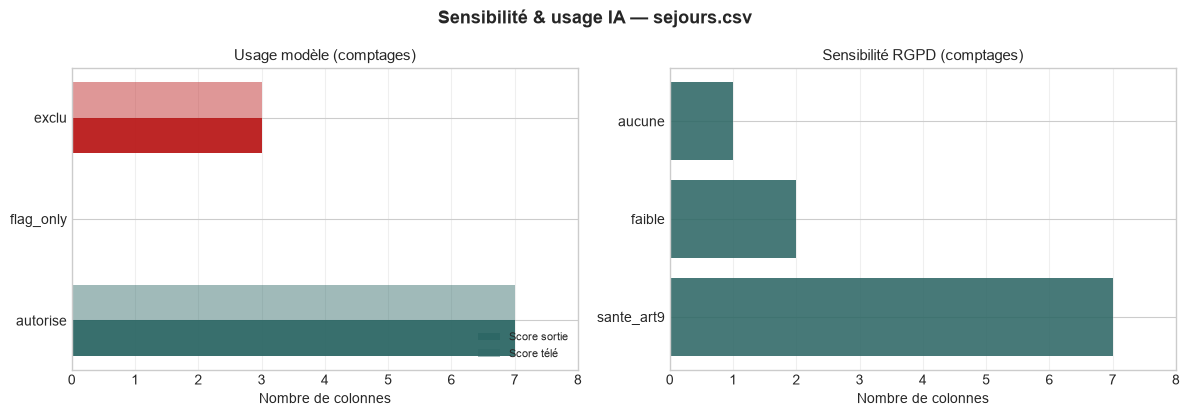

**Détail colonnes — `sejours.csv`**

,colonne,sensibilite,usage_score_sortie,usage_score_tele,risque_principal
0,DateAdmission,sante_art9,autorise,autorise,qualite
1,DateSortie,sante_art9,autorise,autorise,qualite
2,DureeSejour,sante_art9,autorise,autorise,qualite
3,GHM,sante_art9,autorise,autorise,qualite
4,ModeSortie,sante_art9,autorise,autorise,qualite
5,Service,sante_art9,autorise,autorise,qualite
6,TypeSejour,sante_art9,autorise,autorise,qualite
7,Readmission30j,aucune,exclu,exclu,fuite
8,PatientID,faible,exclu,exclu,none
9,SejourID,faible,exclu,exclu,none


### `historique.csv` — 759 lignes

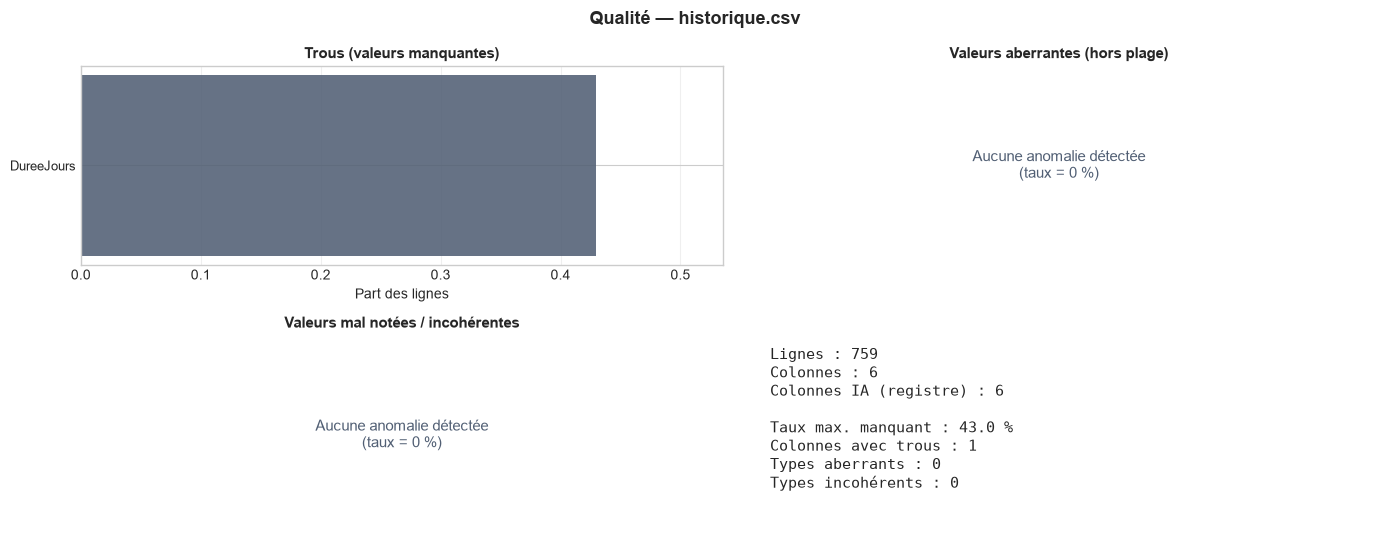

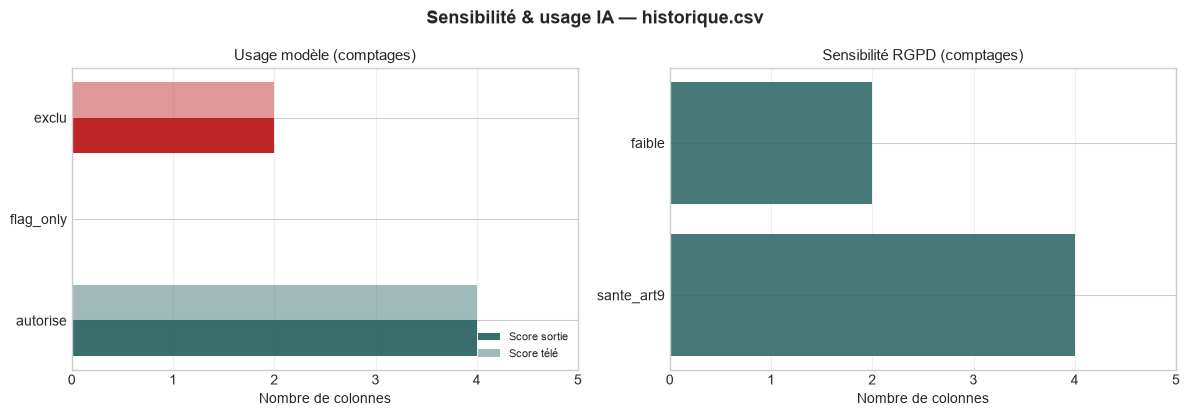

**Détail colonnes — `historique.csv`**

,colonne,sensibilite,usage_score_sortie,usage_score_tele,risque_principal
0,CodeEtablissement,sante_art9,autorise,autorise,qualite
1,DateEvenement,sante_art9,autorise,autorise,qualite
2,DureeJours,sante_art9,autorise,autorise,qualite
3,TypeEvenement,sante_art9,autorise,autorise,qualite
4,EvenementID,faible,exclu,exclu,none
5,PatientID,faible,exclu,exclu,none


### `diagnostics.csv` — 2,062 lignes

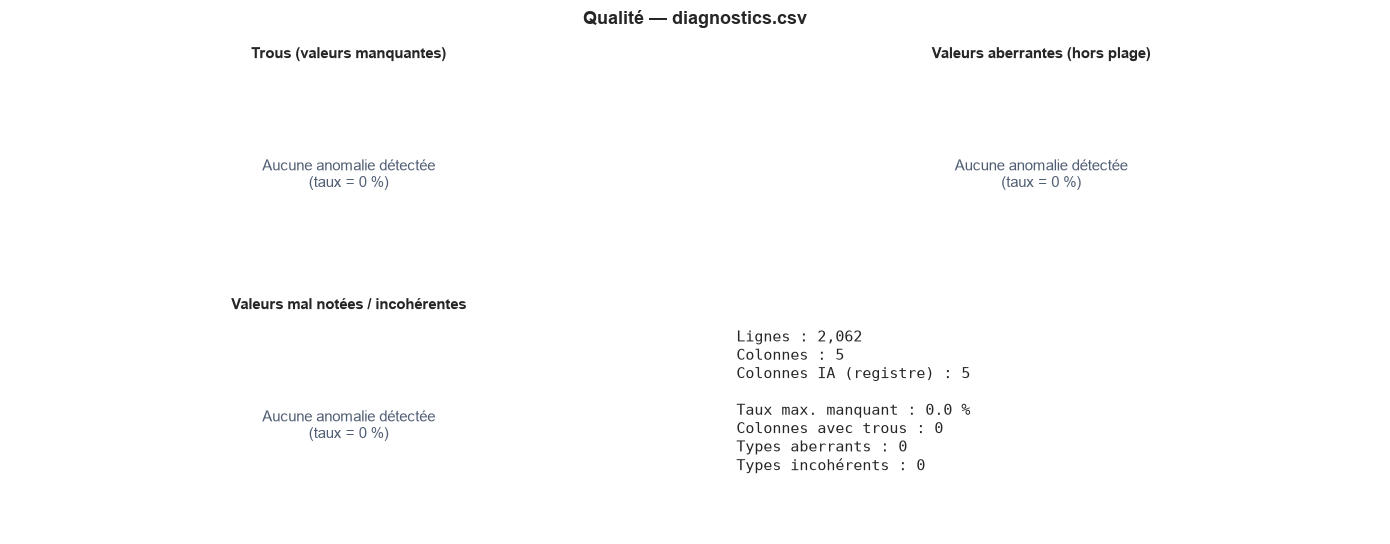

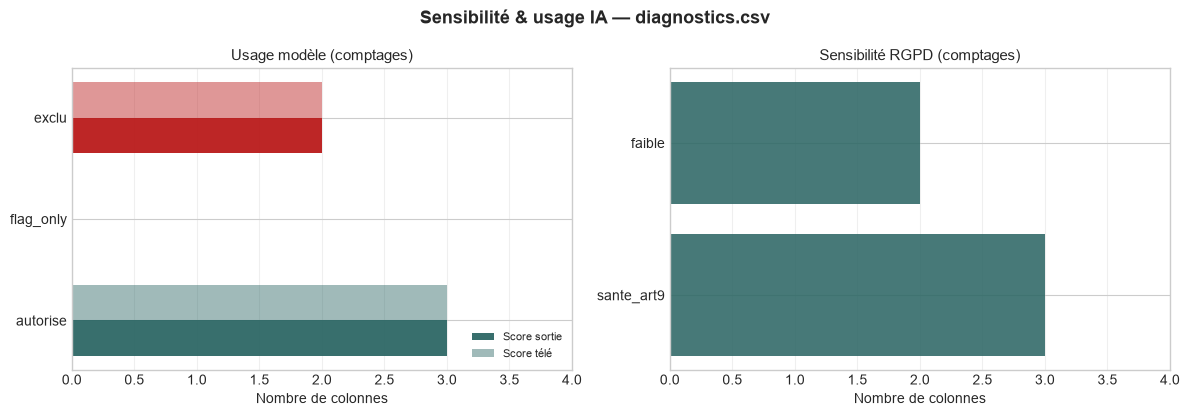

**Détail colonnes — `diagnostics.csv`**

,colonne,sensibilite,usage_score_sortie,usage_score_tele,risque_principal
0,CodeCIM10,sante_art9,autorise,autorise,qualite
1,LibelleDiagnostic,sante_art9,autorise,autorise,qualite
2,Role,sante_art9,autorise,autorise,qualite
3,DiagnosticID,faible,exclu,exclu,none
4,SejourID,faible,exclu,exclu,none


### `actes.csv` — 1,254 lignes

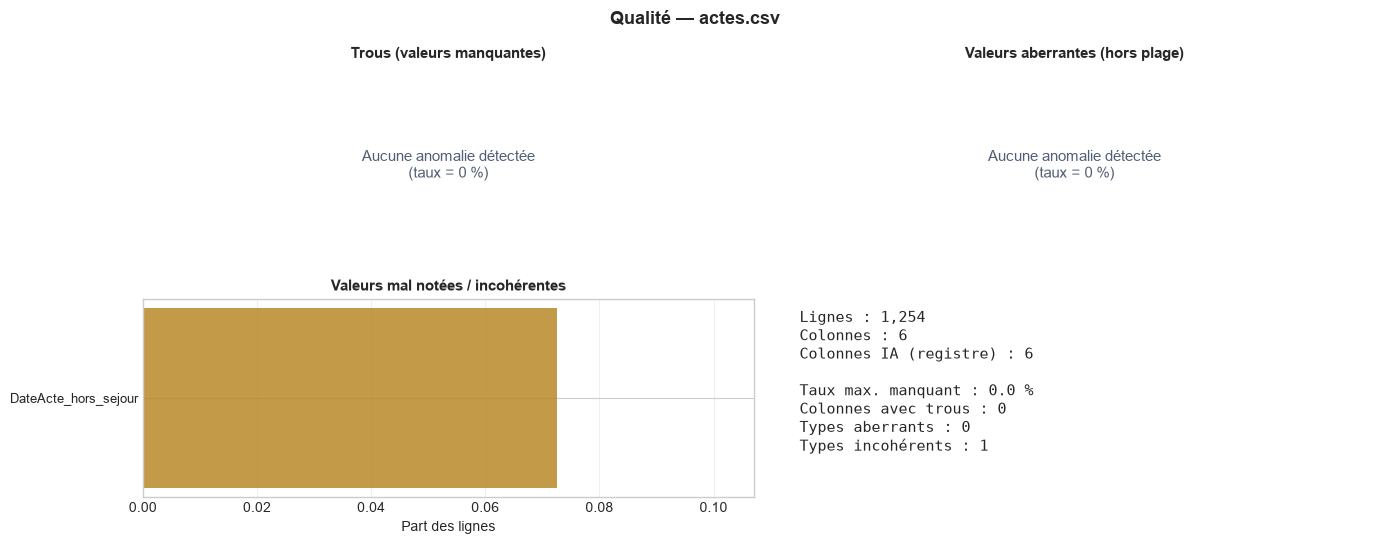

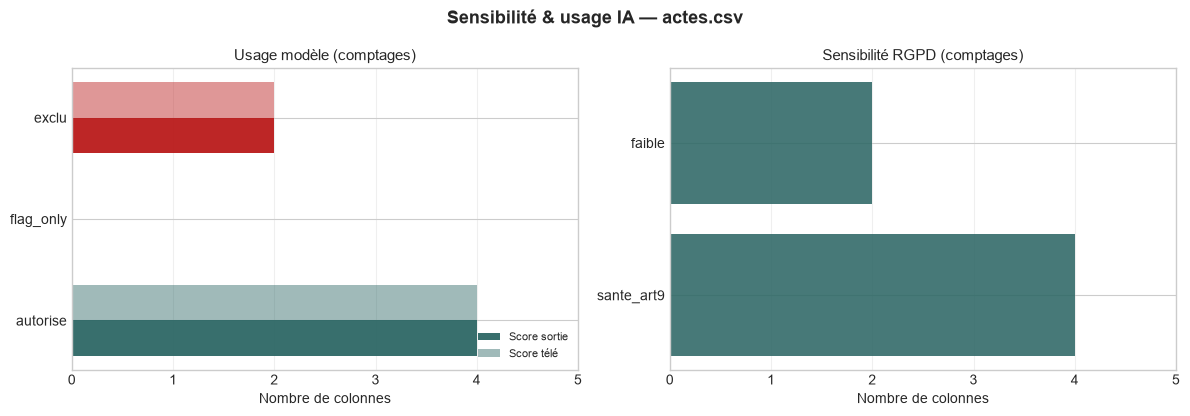

**Détail colonnes — `actes.csv`**

,colonne,sensibilite,usage_score_sortie,usage_score_tele,risque_principal
0,CodeCCAM,sante_art9,autorise,autorise,qualite
1,CodeExecutant,sante_art9,autorise,autorise,qualite
2,DateActe,sante_art9,autorise,autorise,qualite
3,LibelleActe,sante_art9,autorise,autorise,qualite
4,ActeID,faible,exclu,exclu,none
5,SejourID,faible,exclu,exclu,none


### `biologies.csv` — 3,721 lignes

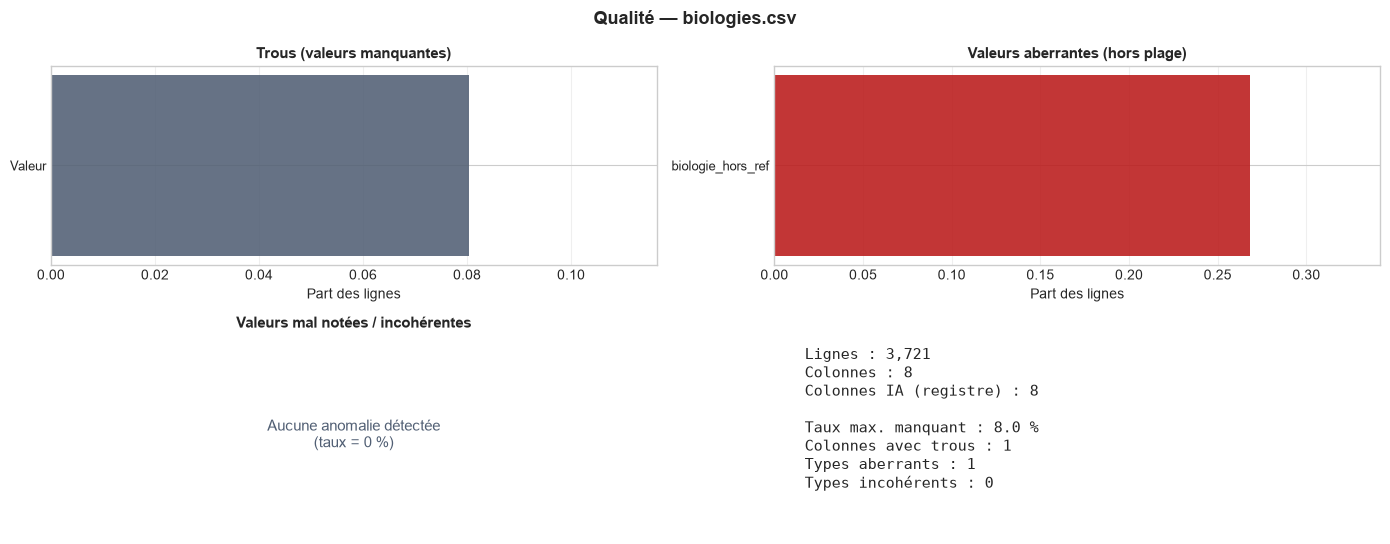

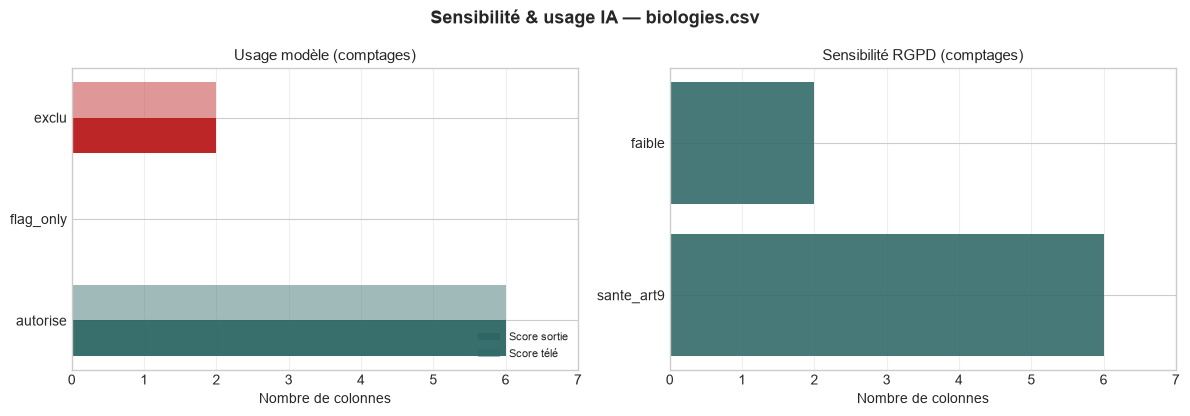

**Détail colonnes — `biologies.csv`**

,colonne,sensibilite,usage_score_sortie,usage_score_tele,risque_principal
0,DatePrelevement,sante_art9,autorise,autorise,qualite
1,Panel,sante_art9,autorise,autorise,qualite
2,Unite,sante_art9,autorise,autorise,qualite
3,Valeur,sante_art9,autorise,autorise,qualite
4,ValeurReferenceBas,sante_art9,autorise,autorise,qualite
5,ValeurReferenceHaut,sante_art9,autorise,autorise,qualite
6,BiologieID,faible,exclu,exclu,none
7,SejourID,faible,exclu,exclu,none


### `signes_vitaux.csv` — 24,916 lignes

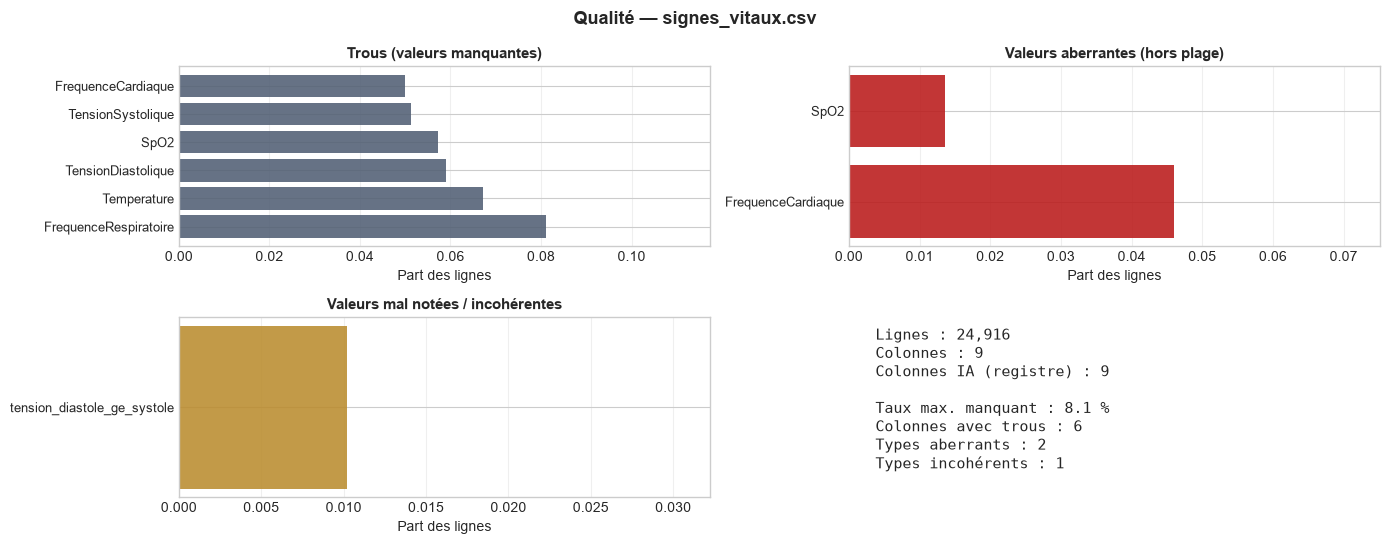

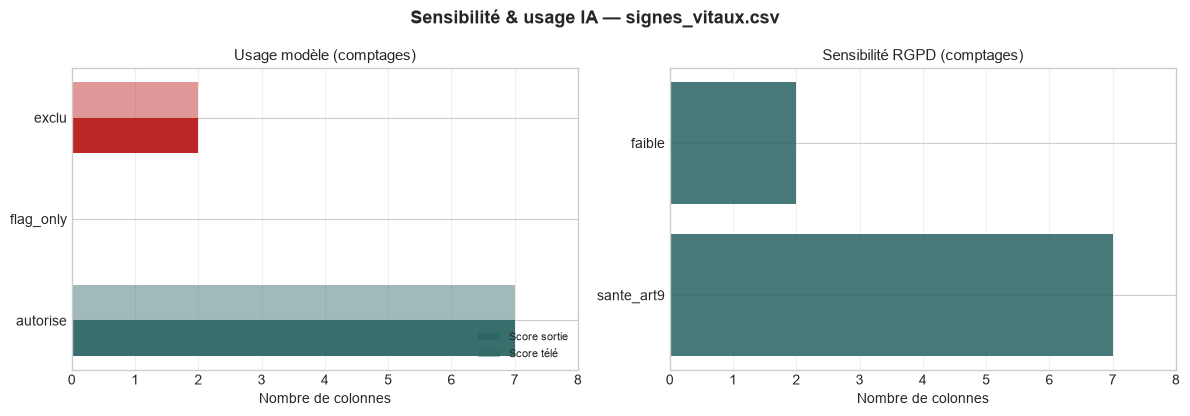

**Détail colonnes — `signes_vitaux.csv`**

,colonne,sensibilite,usage_score_sortie,usage_score_tele,risque_principal
0,FrequenceCardiaque,sante_art9,autorise,autorise,qualite
1,FrequenceRespiratoire,sante_art9,autorise,autorise,qualite
2,Horodatage,sante_art9,autorise,autorise,qualite
3,SpO2,sante_art9,autorise,autorise,qualite
4,Temperature,sante_art9,autorise,autorise,qualite
5,TensionDiastolique,sante_art9,autorise,autorise,qualite
6,TensionSystolique,sante_art9,autorise,autorise,qualite
7,ConstanteID,faible,exclu,exclu,none
8,SejourID,faible,exclu,exclu,none


### `medications.csv` — 3,728 lignes

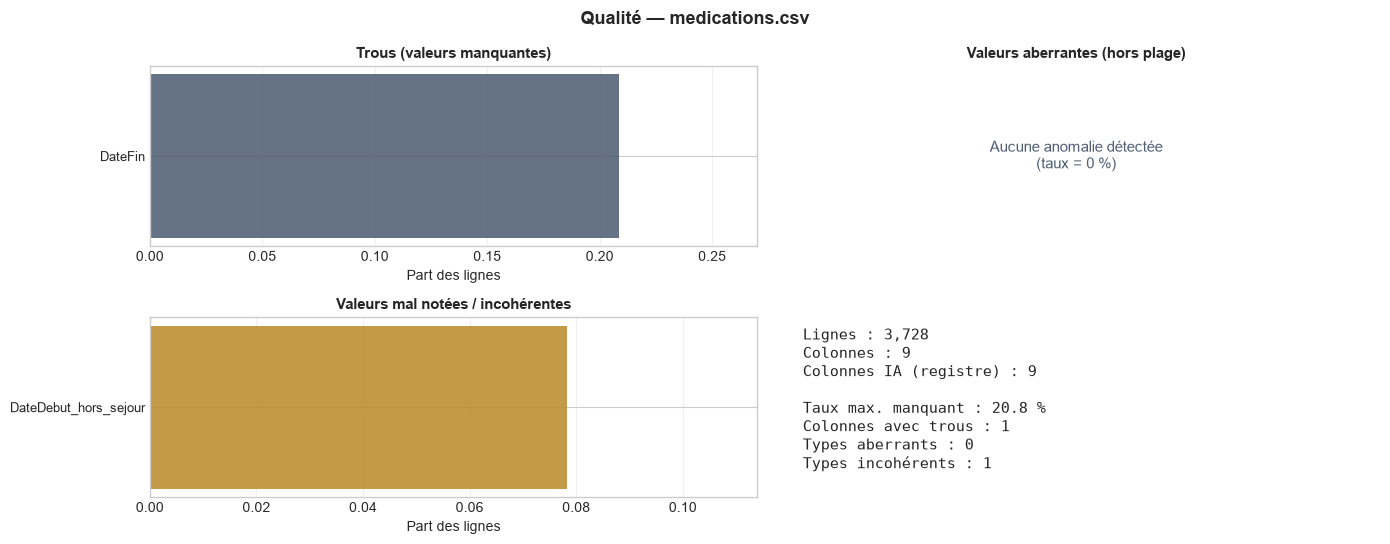

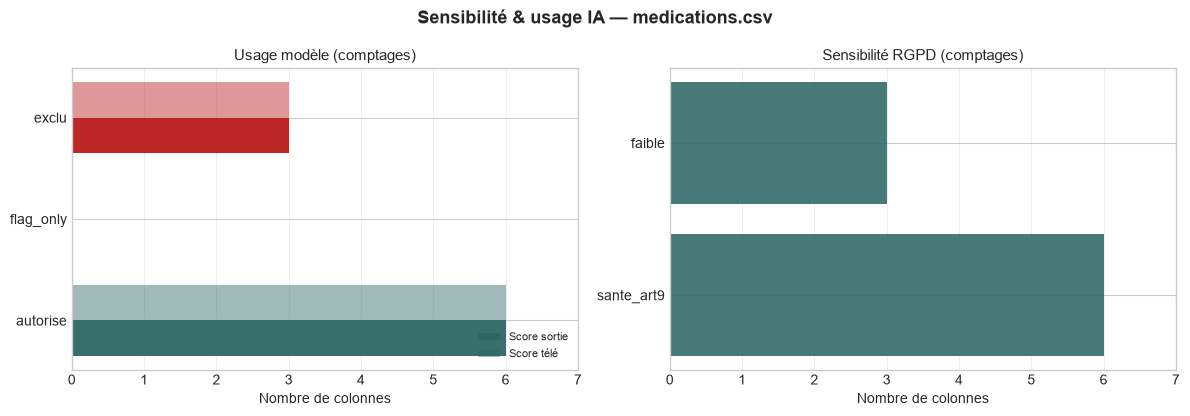

**Détail colonnes — `medications.csv`**

,colonne,sensibilite,usage_score_sortie,usage_score_tele,risque_principal
0,CodeATC,sante_art9,autorise,autorise,qualite
1,DateDebut,sante_art9,autorise,autorise,qualite
2,DateFin,sante_art9,autorise,autorise,qualite
3,LibelleMedicament,sante_art9,autorise,autorise,qualite
4,Posologie,sante_art9,autorise,autorise,qualite
5,Voie,sante_art9,autorise,autorise,qualite
6,PatientID,faible,exclu,exclu,none
7,PrescriptionID,faible,exclu,exclu,none
8,SejourID,faible,exclu,exclu,none


### `comptes_rendus.csv` — 1,144 lignes

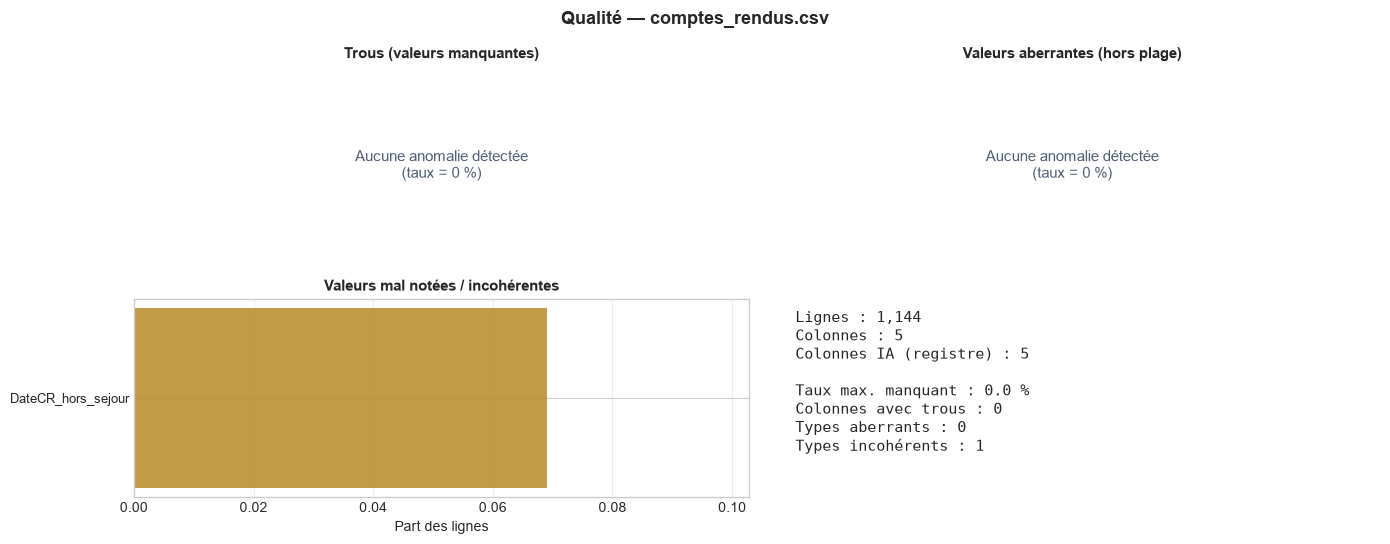

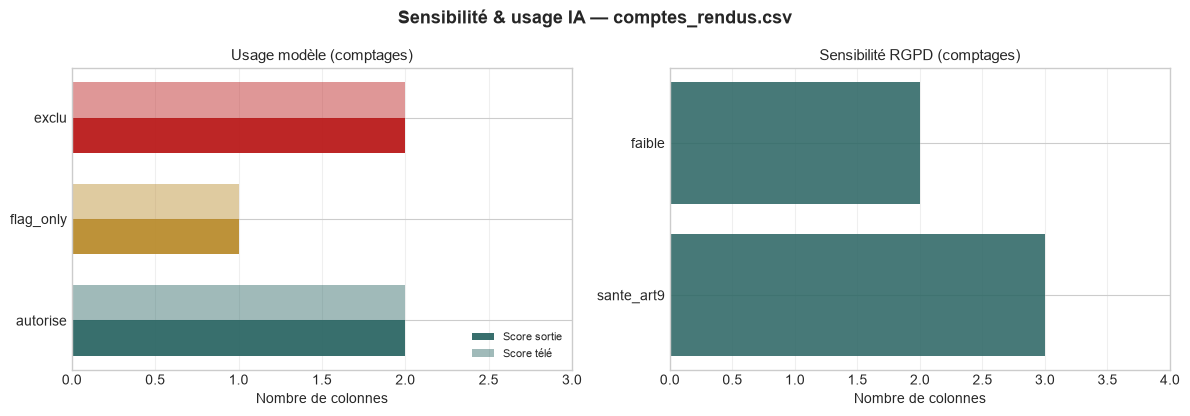

**Détail colonnes — `comptes_rendus.csv`**

,colonne,sensibilite,usage_score_sortie,usage_score_tele,risque_principal
0,DateCR,sante_art9,autorise,autorise,qualite
1,TypeCR,sante_art9,autorise,autorise,qualite
2,CompteRenduID,faible,exclu,exclu,none
3,SejourID,faible,exclu,exclu,none
4,TexteCR,sante_art9,flag_only,flag_only,secret_medical


### `objets_connectes.csv` — 6,297 lignes

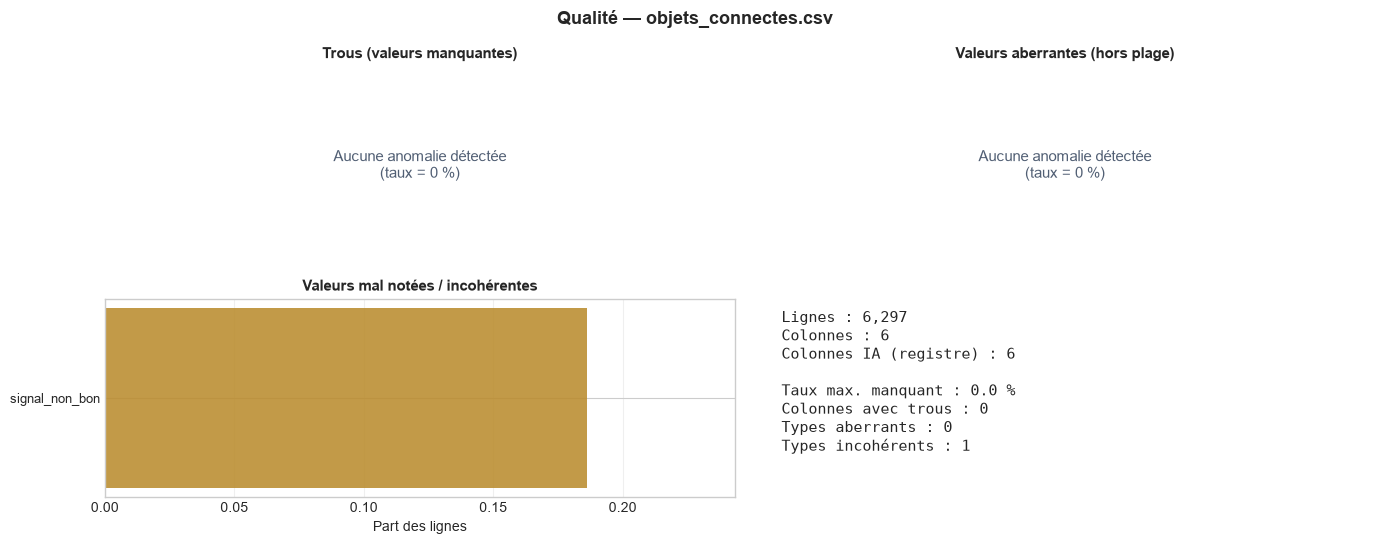

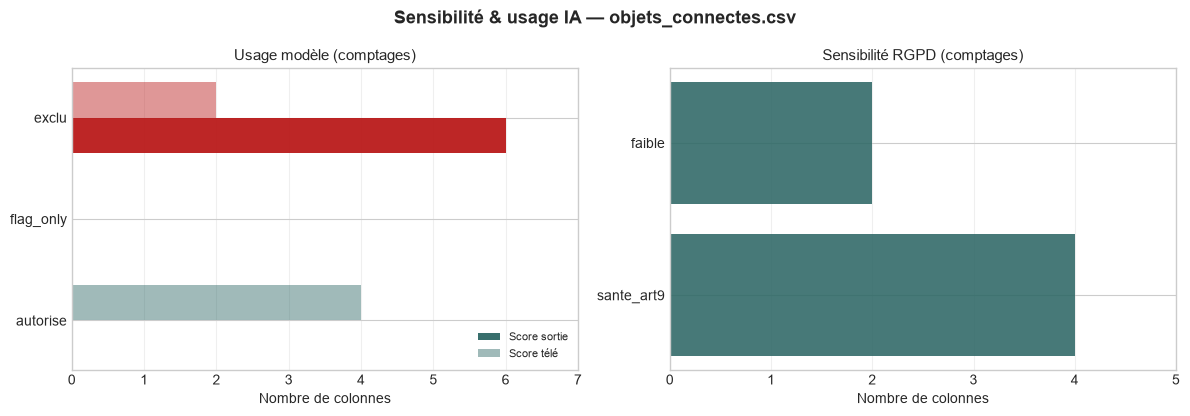

**Détail colonnes — `objets_connectes.csv`**

,colonne,sensibilite,usage_score_sortie,usage_score_tele,risque_principal
0,MesureID,faible,exclu,exclu,none
1,PatientID,faible,exclu,exclu,none
2,Horodatage,sante_art9,exclu,autorise,fuite
3,QualiteSignal,sante_art9,exclu,autorise,fuite
4,TypeMesure,sante_art9,exclu,autorise,fuite
5,Valeur,sante_art9,exclu,autorise,fuite


### `territoire_insee.csv` — 65 lignes

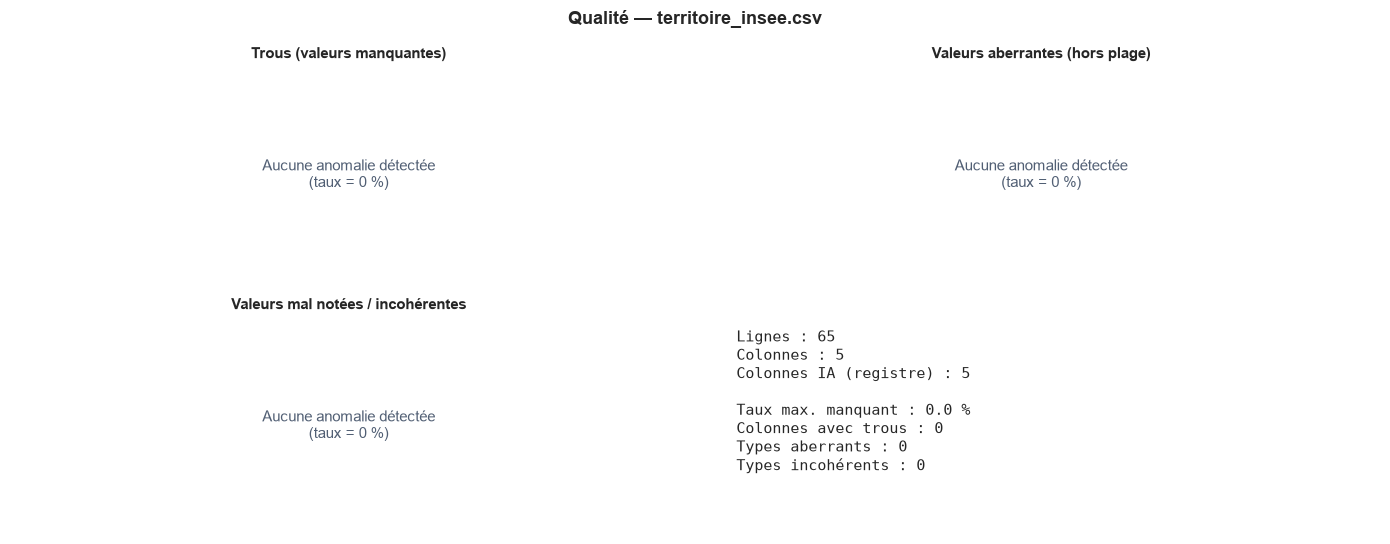

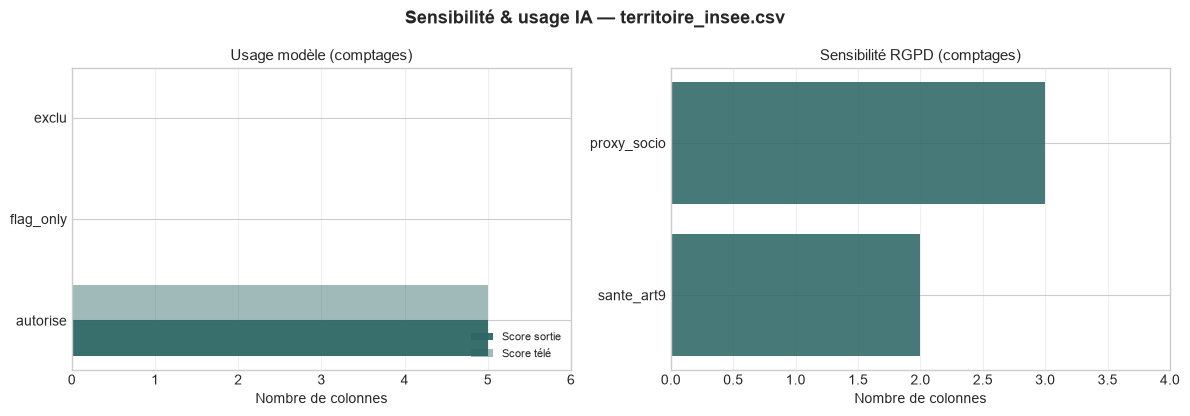

**Détail colonnes — `territoire_insee.csv`**

,colonne,sensibilite,usage_score_sortie,usage_score_tele,risque_principal
0,DensiteMedicale,proxy_socio,autorise,autorise,biais
1,IndiceDefavorisation,proxy_socio,autorise,autorise,biais
2,PopulationCommune,proxy_socio,autorise,autorise,biais
3,CodePostal,sante_art9,autorise,autorise,qualite
4,Commune,sante_art9,autorise,autorise,qualite


In [3]:
for ds in report["datasets"]:
    display(Markdown(f"### `{ds['fichier']}` — {ds['n_lignes']:,} lignes"))
    plot_dataset_qualite(ds)
    if ds.get("sensibilite_ia"):
        plot_sensibilite_ia(ds["sensibilite_ia"], fichier=ds["fichier"])


## Exemples concrets de lignes problématiques

Tableaux issus du code métier (`qualite_data.py`) — ce sont les **hallucinations** à expliquer au jury.


In [4]:
exemples = collecter_exemples_hallucinations(paths)
for nom, df in exemples.items():
    display(Markdown(f"#### `{nom}` ({len(df)} lignes affichées)"))
    display(df)
if not exemples:
    print("Aucun exemple — vérifier les flags dans quality.py / vitals.py")


#### `sejours_duree_incoherente` (12 lignes affichées)

,SejourID,DateAdmission,DateSortie,DureeSejour_brute,DureeSejour
49,SEJ-000050,2023-09-08 20:20:50,2023-09-10 20:20:50,-1,2
50,SEJ-000051,2024-07-01 03:26:12,2024-07-04 03:26:12,-3,3
76,SEJ-000077,2023-11-24 03:51:08,2023-11-26 03:51:08,0,2
84,SEJ-000085,2024-05-31 13:44:26,2024-06-06 13:44:26,99,6
100,SEJ-000101,2024-08-30 00:30:56,2024-09-04 00:30:56,0,5
101,SEJ-000102,2024-05-18 02:50:56,2024-05-27 02:50:56,39,9
175,SEJ-000176,2024-09-17 17:47:06,2024-09-28 17:47:06,41,11
198,SEJ-000199,2023-07-23 00:53:05,2023-07-26 00:53:05,99,3
237,SEJ-000238,2024-10-16 11:56:52,2024-10-27 11:56:52,0,11
254,SEJ-000255,2023-08-02 14:10:04,2023-08-04 14:10:04,-1,2


#### `signes_vitaux_exclus` (12 lignes affichées)

,SejourID,Horodatage,FrequenceCardiaque,TensionSystolique,TensionDiastolique,Temperature,FrequenceRespiratoire,SpO2,motifs_exclusion
3,SEJ-000001,2023-12-25 13:00:00,5.0,104.0,76.0,36.8,22.0,97.0,[Pouls hors plage (30–220 bpm)]
5,SEJ-000001,2023-12-25 22:00:00,0.0,110.0,NaN,36.6,18.0,98.0,[Pouls hors plage (30–220 bpm)]
9,SEJ-000001,2023-12-26 18:00:00,5.0,115.0,79.0,37.5,17.0,93.0,[Pouls hors plage (30–220 bpm)]
14,SEJ-000001,2023-12-27 13:00:00,5.0,106.0,84.0,37.5,18.0,98.0,[Pouls hors plage (30–220 bpm)]
22,SEJ-000001,2023-12-29 02:00:00,240.0,130.0,90.0,36.9,15.0,91.0,[Pouls hors plage (30–220 bpm)]
59,SEJ-000003,2024-03-30 13:00:00,5.0,121.0,86.0,37.2,13.0,94.0,[Pouls hors plage (30–220 bpm)]
78,SEJ-000004,2024-04-14 02:00:00,0.0,108.0,71.0,NaN,20.0,96.0,[Pouls hors plage (30–220 bpm)]
85,SEJ-000004,2024-04-15 04:00:00,5.0,109.0,79.0,38.2,21.0,91.0,[Pouls hors plage (30–220 bpm)]
103,SEJ-000004,2024-04-18 09:00:00,68.0,85.0,94.0,37.0,20.0,93.0,[Tension incohérente (diastole ≥ systole)]
112,SEJ-000004,2024-04-19 20:00:00,93.0,140.0,68.0,35.5,19.0,140.0,[SpO₂ hors plage (50–100 %)]


#### `biologies_aberrantes` (12 lignes affichées)

,SejourID,Panel,Valeur,ValeurReferenceBas,ValeurReferenceHaut
0,SEJ-000001,CRP,-11.33,0,5
9,SEJ-000003,Natremie,999.00,135,145
21,SEJ-000005,CRP,-0.18,0,5
24,SEJ-000006,Hemoglobine,109.38,12,16
31,SEJ-000008,Creatinine,11.05,60,110
36,SEJ-000008,Creatinine,11.23,60,110
37,SEJ-000008,CRP,-5.94,0,5
41,SEJ-000009,CRP,-9.45,0,5
43,SEJ-000010,Hemoglobine,124.64,12,16
46,SEJ-000010,Hemoglobine,121.98,12,16


#### `objets_connectes_signal_faible` (12 lignes affichées)

,MesureID,PatientID,Horodatage,TypeMesure,Valeur,QualiteSignal
2,OC-000003,PAT-00267,2024-04-30 08:00:00,FrequenceCardiaque,67.0,Gap
6,OC-000007,PAT-00267,2024-05-01 14:00:00,FrequenceCardiaque,83.0,CapteurDefaillant
8,OC-000009,PAT-00267,2024-05-02 20:00:00,FrequenceCardiaque,72.0,Gap
20,OC-000021,PAT-00267,2024-05-07 08:00:00,FrequenceCardiaque,50.0,CapteurDefaillant
21,OC-000022,PAT-00267,2024-05-07 14:00:00,SpO2,92.0,Gap
25,OC-000026,PAT-00267,2024-05-09 14:00:00,Poids,62.3,CapteurDefaillant
28,OC-000029,PAT-00267,2024-05-10 14:00:00,ActivitePas,5455.0,CapteurDefaillant
31,OC-000032,PAT-00267,2024-05-11 14:00:00,ActivitePas,5894.0,Gap
36,OC-000037,PAT-00309,2024-05-12 20:00:00,ActivitePas,1321.0,Gap
37,OC-000038,PAT-00309,2024-05-13 08:00:00,ActivitePas,3036.0,CapteurDefaillant


#### `actes_date_hors_sejour` (12 lignes affichées)

,ActeID,SejourID,DateActe,DateAdmission,DateSortie
11,ACT-000012,SEJ-000007,2024-10-25,2024-08-15 10:02:28,2024-08-20 10:02:28
17,ACT-000018,SEJ-000017,2023-09-13,2024-03-21 01:55:32,2024-03-25 01:55:32
44,ACT-000045,SEJ-000033,2022-09-22,2023-10-20 14:14:26,2023-10-24 14:14:26
47,ACT-000048,SEJ-000037,2024-04-20,2024-07-27 14:37:54,2024-07-30 14:37:54
53,ACT-000054,SEJ-000041,2024-06-04,2024-08-15 11:05:55,2024-08-21 11:05:55
79,ACT-000080,SEJ-000060,2023-02-20,2023-08-09 21:08:59,2023-08-17 21:08:59
86,ACT-000087,SEJ-000064,2024-03-17,2024-01-19 00:13:38,2024-01-27 00:13:38
104,ACT-000105,SEJ-000080,2024-02-21,2024-09-29 03:55:36,2024-10-03 03:55:36
111,ACT-000112,SEJ-000083,2023-08-17,2023-10-27 03:08:59,2023-11-01 03:08:59
130,ACT-000131,SEJ-000097,2023-11-26,2024-03-21 07:37:26,2024-03-24 07:37:26


## Légende des types d'anomalie

In [5]:
legende = pd.DataFrame([
    {"type": "sejours_duree_incoherente", "description": "DureeSejour ≠ dates admission/sortie", "gravité": "mal notée"},
    {"type": "signes_vitaux_exclus", "description": "FC/TAS/TAD hors plage ou TAD ≥ TAS", "gravité": "aberrante + exclusion modèle"},
    {"type": "biologies_aberrantes", "description": "Valeur labo hors références ×2", "gravité": "aberrante"},
    {"type": "objets_connectes_signal_faible", "description": "QualiteSignal ≠ Bon", "gravité": "fiabilité télésurveillance"},
    {"type": "actes_date_hors_sejour", "description": "DateActe avant admission ou après sortie", "gravité": "hallucination temporelle"},
])
legende


,type,description,gravité
0,sejours_duree_incoherente,DureeSejour ≠ dates admission/sortie,mal notée
1,signes_vitaux_exclus,FC/TAS/TAD hors plage ou TAD ≥ TAS,aberrante + exclusion modèle
2,biologies_aberrantes,Valeur labo hors références ×2,aberrante
3,objets_connectes_signal_faible,QualiteSignal ≠ Bon,fiabilité télésurveillance
4,actes_date_hors_sejour,DateActe avant admission ou après sortie,hallucination temporelle


## Export rapport HTML

In [6]:
out = export_quality_report(paths)
for k, p in out.items():
    print(f"{k}: {p}")


json: /Users/segalini-briant/Documents/GitHub/CISIA - Sujet Santé/data/curated/qualite/rapport_qualite.json
html: /Users/segalini-briant/Documents/GitHub/CISIA - Sujet Santé/data/curated/qualite/rapport_qualite.html


## Suite du parcours

**Prochaine étape :** [03 — Registre RGPD & usage IA](03_registre_rgpd.ipynb)

| Étape | Notebook |
|-------|----------|
| → **Registre RGPD** (sensibilité & usage modèle) | [`03_registre_rgpd.ipynb`](03_registre_rgpd.ipynb) |
| Analyse qualité complète (nulls, dates, patho) | [`05_analyse_donnees.ipynb`](05_analyse_donnees.ipynb) |
| Pipeline features curated | [`04_pipeline_donnees.ipynb`](04_pipeline_donnees.ipynb) |
| Retour sommaire | [`../00_guide/00_sommaire.ipynb`](../00_guide/00_sommaire.ipynb) |
